# 02b — BODS Deep Dive: Frequency, Service Patterns & Coverage

**Purpose:** Go beyond route/stop counts. Understand the SERVICE LEVEL dimension:
- How many trips per day per route?
- Which stops are well-served vs functionally abandoned?
- Weekday vs weekend service patterns
- Peak vs off-peak frequency
- Geographic distribution of service levels
- Operator market concentration

A stop with 2 buses/day is NOT the same as a stop with 100 buses/day.
Policy makers need to see service frequency, not just stop existence.

**Data:** BODS GTFS (1.57 GB zip) — stop_times.txt is 5.8 GB uncompressed.
We use chunked reading for stop_times.

In [1]:
import pandas as pd
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')
BODS_ZIP = RAW / 'bods' / 'bods_gtfs_all.zip'

print("Loading BODS GTFS core tables...")

Loading BODS GTFS core tables...


In [2]:
# Load all non-huge tables
with zipfile.ZipFile(BODS_ZIP) as z:
    routes = pd.read_csv(z.open('routes.txt'))
    trips = pd.read_csv(z.open('trips.txt'))
    stops = pd.read_csv(z.open('stops.txt'))
    calendar = pd.read_csv(z.open('calendar.txt'))
    calendar_dates = pd.read_csv(z.open('calendar_dates.txt'))
    agency = pd.read_csv(z.open('agency.txt'))
    freq = pd.read_csv(z.open('frequencies.txt'))
    feed_info = pd.read_csv(z.open('feed_info.txt'))

print(f"Routes: {len(routes):,}")
print(f"Trips: {len(trips):,}")
print(f"Stops: {len(stops):,}")
print(f"Calendar: {len(calendar):,}")
print(f"Calendar dates: {len(calendar_dates):,}")
print(f"Agencies: {len(agency):,}")
print(f"Frequencies: {len(freq):,}")
print(f"Feed info: {len(feed_info):,}")

Routes: 13,640
Trips: 1,752,443
Stops: 310,598
Calendar: 2,105
Calendar dates: 179,964
Agencies: 651
Frequencies: 52
Feed info: 1


## 1. Agency / Operator Analysis

Who runs the buses? How concentrated is the market?

=== All Agencies ===
agency_id                                      agency_name                 agency_url agency_timezone agency_lang   agency_phone agency_noc
     OP10                                    M & H Coaches https://www.traveline.info   Europe/London          EN            NaN       MHCO
  OP10066                                K and K Transport https://www.traveline.info   Europe/London          EN   07484 882250       KKTR
    OP101                              Select Bus Services https://www.traveline.info   Europe/London          EN            NaN       SLBS
    OP102                                       LandFlight https://www.traveline.info   Europe/London          EN            NaN       SLVL
  OP10232                                    Solus Coaches https://www.traveline.info   Europe/London          EN            NaN       SOLU
   OP1024                                    Orkney Travel https://www.traveline.info   Europe/London          EN   01856 870340       ORKT

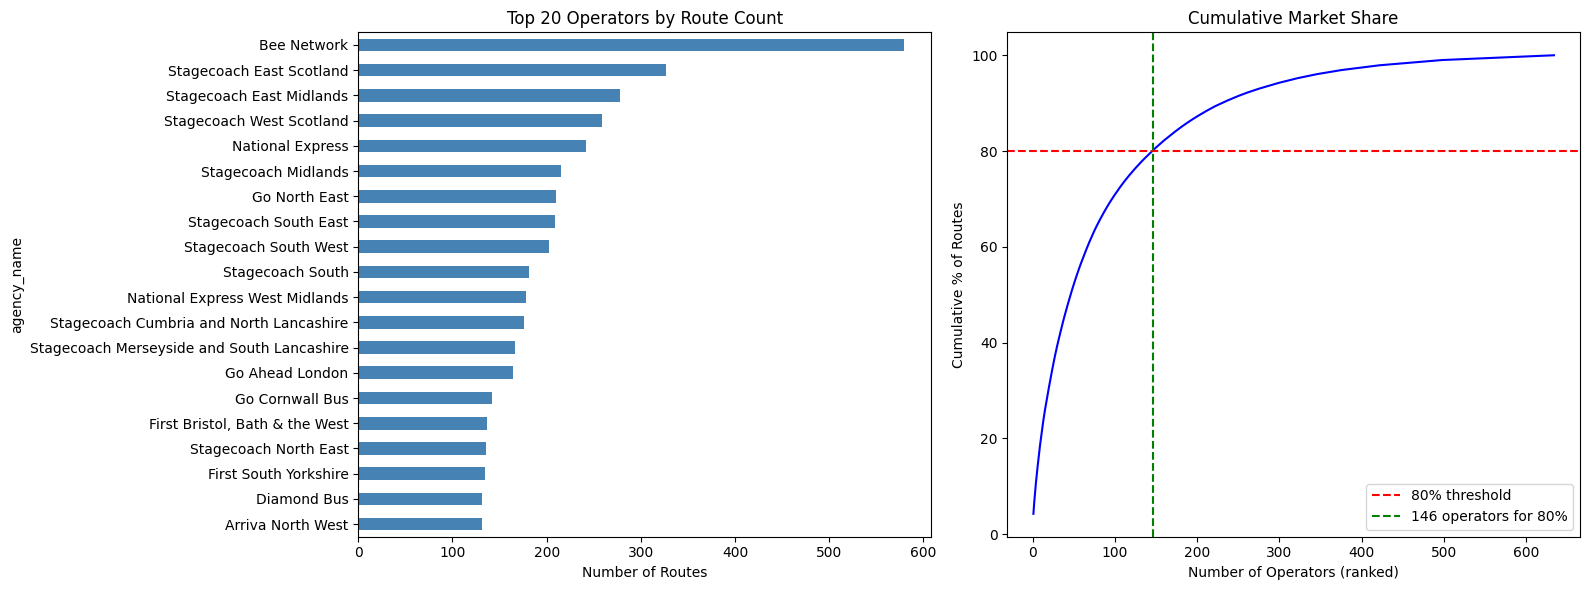

In [3]:
print("=== All Agencies ===")
print(agency.to_string(index=False))

# Routes per agency
routes_per_agency = routes.merge(agency[['agency_id', 'agency_name']], on='agency_id', how='left')
rpa = routes_per_agency['agency_name'].value_counts()
print(f"\n=== Routes per Operator (top 30) ===")
print(rpa.head(30).to_string())

# Market concentration
total_routes = len(routes)
top5_share = rpa.head(5).sum() / total_routes * 100
top10_share = rpa.head(10).sum() / total_routes * 100
print(f"\nMarket concentration:")
print(f"  Top 5 operators: {top5_share:.1f}% of all routes")
print(f"  Top 10 operators: {top10_share:.1f}% of all routes")
print(f"  Total operators: {len(rpa)}")

# Herfindahl-Hirschman Index
shares = (rpa / total_routes * 100)
hhi = (shares ** 2).sum()
print(f"  HHI: {hhi:.0f} (>2500 = highly concentrated, 1500-2500 = moderate)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rpa.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Operators by Route Count')
axes[0].set_xlabel('Number of Routes')
axes[0].invert_yaxis()

# Cumulative market share
cumshare = rpa.cumsum() / total_routes * 100
axes[1].plot(range(1, len(cumshare)+1), cumshare.values, 'b-')
axes[1].axhline(y=80, color='r', linestyle='--', label='80% threshold')
n_80 = (cumshare <= 80).sum() + 1
axes[1].axvline(x=n_80, color='g', linestyle='--', label=f'{n_80} operators for 80%')
axes[1].set_title('Cumulative Market Share')
axes[1].set_xlabel('Number of Operators (ranked)')
axes[1].set_ylabel('Cumulative % of Routes')
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Route Analysis

Route types, naming patterns, geographic coverage.

In [4]:
print("=== Route Columns ===")
print(routes.dtypes.to_string())
print(f"\n=== Route Type Distribution ===")
if 'route_type' in routes.columns:
    rt_map = {0: 'Tram', 1: 'Metro', 2: 'Rail', 3: 'Bus', 4: 'Ferry', 5: 'Cable', 6: 'Gondola', 7: 'Funicular'}
    routes['route_type_name'] = routes['route_type'].map(rt_map).fillna('Unknown')
    print(routes['route_type_name'].value_counts().to_string())

# Route name analysis
if 'route_short_name' in routes.columns:
    print(f"\n=== Route Short Names ===")
    print(f"  Unique: {routes['route_short_name'].nunique()}")
    print(f"  Nulls: {routes['route_short_name'].isna().sum()}")
    print(f"  Sample: {routes['route_short_name'].dropna().head(20).tolist()}")

    # Numeric vs alpha route names
    numeric = routes['route_short_name'].dropna().str.match(r'^\d+$')
    print(f"  Numeric names: {numeric.sum()} ({100*numeric.sum()/len(numeric):.1f}%)")
    print(f"  Alpha/mixed names: {(~numeric).sum()}")

if 'route_long_name' in routes.columns:
    print(f"\n=== Route Long Names ===")
    print(f"  Nulls: {routes['route_long_name'].isna().sum()}")
    print(f"  Sample: {routes['route_long_name'].dropna().head(10).tolist()}")

=== Route Columns ===
route_id              int64
agency_id               str
route_short_name        str
route_long_name     float64
route_type            int64

=== Route Type Distribution ===
route_type_name
Bus        13099
Unknown      361
Ferry        109
Metro         36
Tram          31
Rail           3
Gondola        1

=== Route Short Names ===
  Unique: 3425
  Nulls: 0
  Sample: ['4', '173', '40', '198', 'C9', '47', '2', '4S', 'H59', '22', '29', '43', '14', '60', '025', '61', '76', '10', '22A', '444']
  Numeric names: 8862 (65.0%)
  Alpha/mixed names: 4778

=== Route Long Names ===
  Nulls: 13640
  Sample: []


In [5]:
# Unique route deduplication check
# CRITICAL: Same route can appear in multiple regional feeds
print("=== Route Deduplication Analysis ===")
if 'route_short_name' in routes.columns and 'agency_id' in routes.columns:
    # Same short name + same agency = likely duplicate
    dedup_key = routes[['route_short_name', 'agency_id']].dropna()
    dupes = dedup_key.duplicated(keep=False)
    print(f"  Total routes: {len(routes):,}")
    print(f"  Potential duplicates (same name + agency): {dupes.sum():,}")
    unique_routes = dedup_key.drop_duplicates()
    print(f"  Unique routes (after dedup): {len(unique_routes):,}")

    # Show some examples of duplicates
    if dupes.sum() > 0:
        dupe_examples = routes[dupes].head(10)[['route_id', 'route_short_name', 'agency_id']]
        print(f"\n  Example duplicates:")
        print(dupe_examples.to_string(index=False))

=== Route Deduplication Analysis ===
  Total routes: 13,640
  Potential duplicates (same name + agency): 1,661
  Unique routes (after dedup): 12,646

  Example duplicates:
 route_id route_short_name agency_id
        8                4       OP6
       46               14       OP6
       92               11       OP6
      260               77      OP49
      267               87      OP49
     1677              581     OP268
     3693               21   OP12112
     3695               21     OP152
     3755               63     OP367
     3774                1      OP49


## 3. Trip Volume Analysis

Trips are instances of routes. One route can have hundreds of trips per day.
This is the core of service frequency.

=== Trip Analysis ===
Total trips: 1,752,443


Unique route_ids in trips: 13640


Unique service_ids in trips: 3694

=== Trips per Route Distribution ===
count    13640.000000
mean       128.478226
std        283.875916
min          1.000000
25%          4.000000
50%         25.000000
75%        113.000000
max       6102.000000

  Routes with 1 trip: 477
  Routes with 2-10 trips: 4754
  Routes with 11-50 trips: 3206
  Routes with 51-200 trips: 2897
  Routes with >200 trips: 2306

=== Top 20 Routes by Trip Count ===
route_short_name  n_trips
        Northern     6102
             DLR     4215
        Victoria     4161
              A1     3832
             AIR     3786
         Central     3757
             100     3674
         Jubilee     3501
      Piccadilly     3295
               2     3104
               7     3056
    Metropolitan     3036
        District     3009
              54     2944
              C1     2940
    Metropolitan     2721
              17     2695
               3     2647
               1     2609
               1     2578


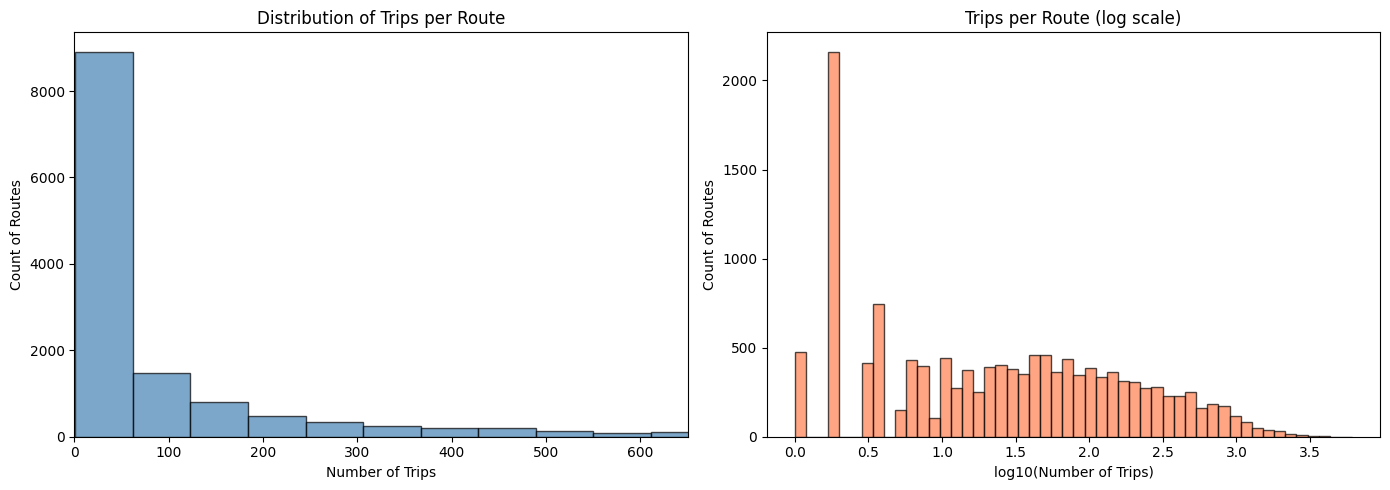

In [6]:
print("=== Trip Analysis ===")
print(f"Total trips: {len(trips):,}")
print(f"Unique route_ids in trips: {trips['route_id'].nunique()}")
print(f"Unique service_ids in trips: {trips['service_id'].nunique()}")

# Trips per route
tpr = trips.groupby('route_id').size().reset_index(name='n_trips')
tpr = tpr.merge(routes[['route_id', 'route_short_name']], on='route_id', how='left')

print(f"\n=== Trips per Route Distribution ===")
print(tpr['n_trips'].describe().to_string())
print(f"\n  Routes with 1 trip: {(tpr['n_trips'] == 1).sum()}")
print(f"  Routes with 2-10 trips: {((tpr['n_trips'] >= 2) & (tpr['n_trips'] <= 10)).sum()}")
print(f"  Routes with 11-50 trips: {((tpr['n_trips'] > 10) & (tpr['n_trips'] <= 50)).sum()}")
print(f"  Routes with 51-200 trips: {((tpr['n_trips'] > 50) & (tpr['n_trips'] <= 200)).sum()}")
print(f"  Routes with >200 trips: {(tpr['n_trips'] > 200).sum()}")

# Top routes by trip count
print(f"\n=== Top 20 Routes by Trip Count ===")
top_routes = tpr.nlargest(20, 'n_trips')
print(top_routes[['route_short_name', 'n_trips']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(tpr['n_trips'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Trips per Route')
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Count of Routes')
axes[0].set_xlim(0, tpr['n_trips'].quantile(0.95))

axes[1].hist(np.log10(tpr['n_trips'].clip(lower=1)), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Trips per Route (log scale)')
axes[1].set_xlabel('log10(Number of Trips)')
axes[1].set_ylabel('Count of Routes')
plt.tight_layout()
plt.show()

In [7]:
# Direction analysis — inbound vs outbound
if 'direction_id' in trips.columns:
    print("=== Direction Analysis ===")
    print(trips['direction_id'].value_counts().to_string())
    print(f"\nRoutes with both directions: {trips.groupby('route_id')['direction_id'].nunique().eq(2).sum()}")
    print(f"Routes with one direction only: {trips.groupby('route_id')['direction_id'].nunique().eq(1).sum()}")

=== Direction Analysis ===
direction_id
0    934578
1    817865



Routes with both directions: 10833
Routes with one direction only: 2807


## 4. Calendar & Service Day Patterns

Which days do services run? How does weekend coverage compare to weekday?

In [8]:
day_cols = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
available_days = [d for d in day_cols if d in calendar.columns]

print("=== Calendar Analysis ===")
print(f"Total service patterns: {len(calendar):,}")

if available_days:
    print(f"\n=== Services Running by Day ===")
    for d in available_days:
        n = calendar[d].sum()
        print(f"  {d.title()}: {n:,} ({100*n/len(calendar):.1f}%)")

    # Service pattern combinations
    calendar['pattern'] = calendar[available_days].apply(lambda r: ''.join(str(int(v)) for v in r), axis=1)
    pattern_counts = calendar['pattern'].value_counts()
    print(f"\n=== Top 15 Service Day Patterns ===")
    print("(1=runs, 0=doesn't — Mon-Tue-Wed-Thu-Fri-Sat-Sun)")
    for pattern, count in pattern_counts.head(15).items():
        days_str = '/'.join([d[:3].title() for d, v in zip(available_days, pattern) if v == '1'])
        print(f"  {pattern}: {count:,} services ({days_str})")

    # Weekday vs weekend coverage
    calendar['n_weekdays'] = calendar[available_days[:5]].sum(axis=1)
    calendar['n_weekend'] = calendar[available_days[5:]].sum(axis=1)

    print(f"\n=== Weekday vs Weekend ===")
    wk_only = len(calendar[(calendar['n_weekdays'] > 0) & (calendar['n_weekend'] == 0)])
    we_only = len(calendar[(calendar['n_weekdays'] == 0) & (calendar['n_weekend'] > 0)])
    both = len(calendar[(calendar['n_weekdays'] > 0) & (calendar['n_weekend'] > 0)])
    print(f"  Weekday-only: {wk_only:,} ({100*wk_only/len(calendar):.1f}%)")
    print(f"  Weekend-only: {we_only:,} ({100*we_only/len(calendar):.1f}%)")
    print(f"  Both: {both:,} ({100*both/len(calendar):.1f}%)")

    # Saturday vs Sunday
    if 'saturday' in calendar.columns and 'sunday' in calendar.columns:
        sat_services = calendar['saturday'].sum()
        sun_services = calendar['sunday'].sum()
        print(f"\n  Saturday services: {sat_services:,}")
        print(f"  Sunday services: {sun_services:,}")
        print(f"  Sunday/Saturday ratio: {sun_services/sat_services:.2f}" if sat_services > 0 else "")

=== Calendar Analysis ===
Total service patterns: 2,105

=== Services Running by Day ===
  Monday: 1,049 (49.8%)
  Tuesday: 1,016 (48.3%)
  Wednesday: 1,017 (48.3%)
  Thursday: 1,027 (48.8%)
  Friday: 1,063 (50.5%)
  Saturday: 490 (23.3%)
  Sunday: 435 (20.7%)

=== Top 15 Service Day Patterns ===
(1=runs, 0=doesn't — Mon-Tue-Wed-Thu-Fri-Sat-Sun)
  1111100: 506 services (Mon/Tue/Wed/Thu/Fri)
  0000010: 258 services (Sat)
  0000001: 236 services (Sun)
  0000100: 132 services (Fri)
  1000000: 97 services (Mon)
  1111000: 82 services (Mon/Tue/Wed/Thu)
  1111111: 72 services (Mon/Tue/Wed/Thu/Fri/Sat/Sun)
  0010000: 61 services (Wed)
  0100000: 61 services (Tue)
  0001000: 48 services (Thu)
  1111110: 39 services (Mon/Tue/Wed/Thu/Fri/Sat)
  0111100: 35 services (Tue/Wed/Thu/Fri)
  0101000: 28 services (Tue/Thu)
  1101100: 27 services (Mon/Tue/Thu/Fri)
  0111000: 27 services (Tue/Wed/Thu)

=== Weekday vs Weekend ===
  Weekday-only: 1,332 (63.3%)
  Weekend-only: 515 (24.5%)
  Both: 258 (12.3%)

In [9]:
# Calendar: Date ranges
if 'start_date' in calendar.columns:
    calendar['start_date_dt'] = pd.to_datetime(calendar['start_date'], format='%Y%m%d', errors='coerce')
    calendar['end_date_dt'] = pd.to_datetime(calendar['end_date'], format='%Y%m%d', errors='coerce')

    print("=== Service Date Ranges ===")
    print(f"  Earliest start: {calendar['start_date_dt'].min()}")
    print(f"  Latest start: {calendar['start_date_dt'].max()}")
    print(f"  Earliest end: {calendar['end_date_dt'].min()}")
    print(f"  Latest end: {calendar['end_date_dt'].max()}")

    # Service duration distribution
    calendar['duration_days'] = (calendar['end_date_dt'] - calendar['start_date_dt']).dt.days
    print(f"\n  Service duration (days):")
    print(f"    Mean: {calendar['duration_days'].mean():.0f}")
    print(f"    Median: {calendar['duration_days'].median():.0f}")
    print(f"    Min: {calendar['duration_days'].min()}")
    print(f"    Max: {calendar['duration_days'].max()}")

=== Service Date Ranges ===
  Earliest start: 2026-03-11 00:00:00
  Latest start: 2125-07-03 00:00:00
  Earliest end: 2026-03-11 00:00:00
  Latest end: 2125-09-28 00:00:00

  Service duration (days):
    Mean: 163
    Median: 171
    Min: 0
    Max: 276


In [10]:
# Calendar dates — exceptions
print("=== Calendar Dates (Exceptions) ===")
print(f"Total exceptions: {len(calendar_dates):,}")
if 'exception_type' in calendar_dates.columns:
    print(f"\nException types:")
    print(f"  1 (service added): {(calendar_dates['exception_type'] == 1).sum():,}")
    print(f"  2 (service removed): {(calendar_dates['exception_type'] == 2).sum():,}")

=== Calendar Dates (Exceptions) ===
Total exceptions: 179,964

Exception types:
  1 (service added): 83,339
  2 (service removed): 96,625


## 5. Stop Times — Service Frequency Analysis (chunked reading)

This is the heart of the BODS deep dive. stop_times.txt tells us WHEN
each trip visits each stop. From this we derive:
- Trips per stop per day
- First/last service times
- Peak vs off-peak patterns
- Service frequency at each stop

In [11]:
# Read stop_times in chunks — file is ~5.8 GB
print("Reading stop_times.txt in chunks (5.8 GB file)...")
print("Computing: trips per stop, time-of-day distribution, first/last service")

# We need: stop_id → trip_id mapping, and arrival_time for time analysis
# Strategy: iterate chunks, accumulate stop-level stats

stop_trip_counts = Counter()  # stop_id → number of trip visits
stop_first_time = {}  # stop_id → earliest arrival
stop_last_time = {}  # stop_id → latest arrival
hour_distribution = Counter()  # hour → count of stop visits
total_rows = 0

with zipfile.ZipFile(BODS_ZIP) as z:
    reader = pd.read_csv(z.open('stop_times.txt'), chunksize=500000,
                         usecols=['trip_id', 'stop_id', 'arrival_time', 'stop_sequence'],
                         dtype={'stop_id': str, 'trip_id': str})

    for i, chunk in enumerate(reader):
        total_rows += len(chunk)

        # Count trip visits per stop
        for stop_id, count in chunk['stop_id'].value_counts().items():
            stop_trip_counts[stop_id] += count

        # Time analysis — extract hour from arrival_time (HH:MM:SS format)
        # Note: GTFS allows times > 24:00:00 for services past midnight
        valid_times = chunk['arrival_time'].dropna()
        hours = valid_times.str.split(':', expand=True)[0].astype(int, errors='ignore')
        for h, count in hours.value_counts().items():
            try:
                hour_distribution[int(h)] += count
            except (ValueError, TypeError):
                pass

        if (i + 1) % 20 == 0:
            print(f"  Processed {total_rows:,} rows ({i+1} chunks)...")

print(f"\nTotal stop_times rows: {total_rows:,}")
print(f"Unique stops visited: {len(stop_trip_counts):,}")

Reading stop_times.txt in chunks (5.8 GB file)...
Computing: trips per stop, time-of-day distribution, first/last service


  Processed 10,000,000 rows (20 chunks)...


  Processed 20,000,000 rows (40 chunks)...


  Processed 30,000,000 rows (60 chunks)...


  Processed 40,000,000 rows (80 chunks)...


  Processed 50,000,000 rows (100 chunks)...


  Processed 60,000,000 rows (120 chunks)...



Total stop_times rows: 68,685,917
Unique stops visited: 309,541


In [12]:
# Convert to DataFrames for analysis
stop_freq = pd.DataFrame([
    {'stop_id': k, 'total_visits': v}
    for k, v in stop_trip_counts.items()
]).sort_values('total_visits', ascending=False)

print(f"=== Stop Visit Frequency ===")
print(f"  Total stop visits: {stop_freq['total_visits'].sum():,}")
print(stop_freq['total_visits'].describe().to_string())

print(f"\n=== Visit Frequency Bands ===")
bins = [0, 10, 50, 100, 500, 1000, 5000, float('inf')]
labels = ['1-10', '11-50', '51-100', '101-500', '501-1K', '1K-5K', '5K+']
stop_freq['band'] = pd.cut(stop_freq['total_visits'], bins=bins, labels=labels)
band_counts = stop_freq['band'].value_counts().sort_index()
for band, count in band_counts.items():
    print(f"  {band} visits: {count:,} stops ({100*count/len(stop_freq):.1f}%)")

# The bottom: stops with almost no service
print(f"\n=== Underserved Stops ===")
print(f"  Stops with ≤5 visits (total): {(stop_freq['total_visits'] <= 5).sum():,}")
print(f"  Stops with ≤10 visits: {(stop_freq['total_visits'] <= 10).sum():,}")
print(f"  Stops with ≤50 visits: {(stop_freq['total_visits'] <= 50).sum():,}")

# The top: busiest stops
print(f"\n=== Top 20 Busiest Stops ===")
top_stops = stop_freq.head(20).merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')
print(top_stops[['stop_name', 'total_visits']].to_string(index=False))

=== Stop Visit Frequency ===
  Total stop visits: 68,685,917
count    309541.000000
mean        221.896023
std         427.657978
min           1.000000
25%          22.000000
50%          75.000000
75%         230.000000
max       10417.000000

=== Visit Frequency Bands ===
  1-10 visits: 45,938 stops (14.8%)
  11-50 visits: 82,104 stops (26.5%)
  51-100 visits: 47,372 stops (15.3%)
  101-500 visits: 98,440 stops (31.8%)
  501-1K visits: 21,542 stops (7.0%)
  1K-5K visits: 14,012 stops (4.5%)
  5K+ visits: 133 stops (0.0%)

=== Underserved Stops ===
  Stops with ≤5 visits (total): 28,698
  Stops with ≤10 visits: 45,938
  Stops with ≤50 visits: 128,042

=== Top 20 Busiest Stops ===
                 stop_name  total_visits
                Old Steine         10417
             Retail Market          9161
         St Patrick Square          8599
                   Parkway          8562
Chelmsford Railway Station          8537
           Bernard Terrace          8502
                HMS Ne

=== Time-of-Day Distribution (all stop visits) ===


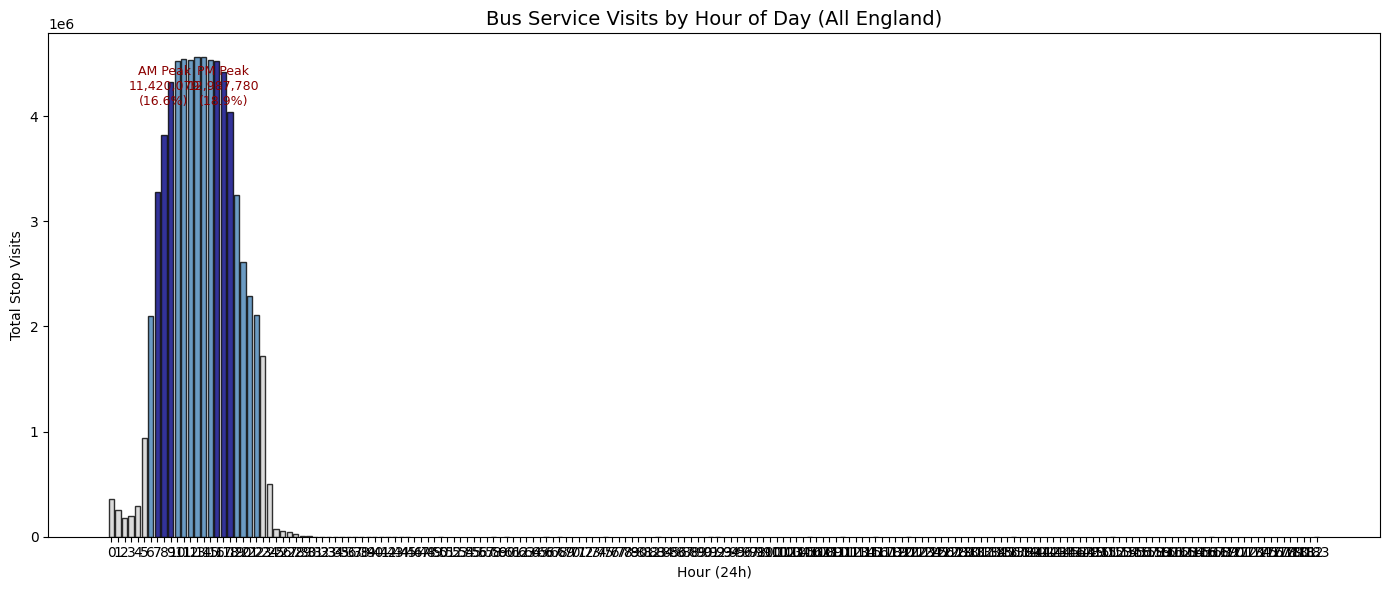

In [13]:
# Time-of-day distribution
print("=== Time-of-Day Distribution (all stop visits) ===")
hours_df = pd.DataFrame([
    {'hour': h, 'visits': c}
    for h, c in sorted(hour_distribution.items())
])

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['navy' if 7 <= h <= 9 or 16 <= h <= 18 else 'steelblue' if 6 <= h <= 22 else 'lightgray'
          for h in hours_df['hour']]
ax.bar(hours_df['hour'], hours_df['visits'], color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Bus Service Visits by Hour of Day (All England)', fontsize=14)
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Total Stop Visits')
ax.set_xticks(range(0, max(hours_df['hour'])+1))

# Annotate peaks
peak_am = hours_df.loc[hours_df['hour'].between(7, 9), 'visits'].sum()
peak_pm = hours_df.loc[hours_df['hour'].between(16, 18), 'visits'].sum()
offpeak = hours_df.loc[hours_df['hour'].between(10, 15), 'visits'].sum()
total_vis = hours_df['visits'].sum()
ax.text(8, hours_df['visits'].max()*0.9, f'AM Peak\n{peak_am:,}\n({100*peak_am/total_vis:.1f}%)',
        ha='center', fontsize=9, color='darkred')
ax.text(17, hours_df['visits'].max()*0.9, f'PM Peak\n{peak_pm:,}\n({100*peak_pm/total_vis:.1f}%)',
        ha='center', fontsize=9, color='darkred')
plt.tight_layout()
plt.show()

In [14]:
# Night service analysis (past midnight = hour > 23)
night_hours = hours_df[hours_df['hour'] >= 24]
if len(night_hours) > 0:
    print("=== After-Midnight Services ===")
    for _, row in night_hours.iterrows():
        real_hour = row['hour'] - 24
        print(f"  {int(row['hour'])}:00 (= {int(real_hour)}:00 next day): {int(row['visits']):,} visits")
else:
    print("No after-midnight services found (hours ≤ 23)")

early = hours_df[hours_df['hour'] <= 5]
print(f"\nEarly morning (before 6am): {early['visits'].sum():,} visits")
late = hours_df[hours_df['hour'] >= 22]
print(f"Late evening (22:00+): {late['visits'].sum():,} visits")

=== After-Midnight Services ===
  24:00 (= 0:00 next day): 500,514 visits
  25:00 (= 1:00 next day): 75,061 visits
  26:00 (= 2:00 next day): 54,422 visits
  27:00 (= 3:00 next day): 45,743 visits
  28:00 (= 4:00 next day): 23,900 visits
  29:00 (= 5:00 next day): 8,379 visits
  30:00 (= 6:00 next day): 2,413 visits
  31:00 (= 7:00 next day): 292 visits
  32:00 (= 8:00 next day): 112 visits
  33:00 (= 9:00 next day): 103 visits
  34:00 (= 10:00 next day): 48 visits
  35:00 (= 11:00 next day): 16 visits
  36:00 (= 12:00 next day): 23 visits
  37:00 (= 13:00 next day): 15 visits
  38:00 (= 14:00 next day): 18 visits
  39:00 (= 15:00 next day): 12 visits
  40:00 (= 16:00 next day): 13 visits
  41:00 (= 17:00 next day): 8 visits
  42:00 (= 18:00 next day): 7 visits
  43:00 (= 19:00 next day): 10 visits
  44:00 (= 20:00 next day): 12 visits
  45:00 (= 21:00 next day): 7 visits
  50:00 (= 26:00 next day): 1 visits
  58:00 (= 34:00 next day): 1 visits
  60:00 (= 36:00 next day): 1 visits
  66

## 6. Stop Geographic Analysis

Where are the BODS stops? How do they relate to NaPTAN?

In [15]:
print("=== BODS Stops Geographic Profile ===")
if 'stop_lat' in stops.columns and 'stop_lon' in stops.columns:
    print(f"Stops with coordinates: {stops[['stop_lat', 'stop_lon']].notna().all(axis=1).sum():,} / {len(stops):,}")
    print(f"Latitude range: [{stops['stop_lat'].min():.4f}, {stops['stop_lat'].max():.4f}]")
    print(f"Longitude range: [{stops['stop_lon'].min():.4f}, {stops['stop_lon'].max():.4f}]")

    # Likely England bounds: lat 49.9-56, lon -6 to 2
    england_lat = stops['stop_lat'].between(49.9, 56)
    england_lon = stops['stop_lon'].between(-6, 2)
    in_england = england_lat & england_lon
    print(f"\nStops within England bounds: {in_england.sum():,}")
    print(f"Stops outside England bounds: {(~in_england).sum():,}")
    if (~in_england).sum() > 0:
        print("  (These may be Scottish/Welsh stops in cross-border routes)")

# Stop ID format analysis
print(f"\n=== Stop ID Formats ===")
print(f"Unique stop_ids: {stops['stop_id'].nunique():,}")
# Check if they match NaPTAN ATCOCode format
atco_pattern = stops['stop_id'].str.match(r'^\d{3}[0-9A-Z]')
print(f"Match ATCO format: {atco_pattern.sum():,}")
print(f"Non-ATCO format: {(~atco_pattern).sum():,}")
print(f"Sample non-ATCO: {stops[~atco_pattern]['stop_id'].head(10).tolist()}")

=== BODS Stops Geographic Profile ===
Stops with coordinates: 310,598 / 310,598
Latitude range: [0.1903, 60.8090]
Longitude range: [-7.5434, 52.2756]

Stops within England bounds: 292,797
Stops outside England bounds: 17,801
  (These may be Scottish/Welsh stops in cross-border routes)

=== Stop ID Formats ===


Unique stop_ids: 310,598
Match ATCO format: 310,598
Non-ATCO format: 0
Sample non-ATCO: []


## 7. Trips ↔ Service ↔ Calendar Join — Estimating Daily Frequencies

Join trips → calendar to estimate how many trips run on a typical weekday
vs Saturday vs Sunday. This gives us the service frequency dimension.

In [16]:
# Join trips to calendar
trip_cal = trips.merge(calendar[['service_id'] + available_days], on='service_id', how='left')

# Compute trips per route on each day type
route_day_trips = {}
for day in available_days:
    day_trips = trip_cal[trip_cal[day] == 1].groupby('route_id').size()
    route_day_trips[day] = day_trips

print("=== Route-level Service Frequency by Day ===")
for day in available_days:
    dt = route_day_trips[day]
    print(f"\n{day.title()}:")
    print(f"  Routes with service: {len(dt):,}")
    print(f"  Total trips: {dt.sum():,}")
    print(f"  Trips per route: mean={dt.mean():.1f}, median={dt.median():.0f}, max={dt.max()}")

=== Route-level Service Frequency by Day ===

Monday:
  Routes with service: 9,885
  Total trips: 605,427
  Trips per route: mean=61.2, median=24, max=1583

Tuesday:
  Routes with service: 9,903
  Total trips: 591,862
  Trips per route: mean=59.8, median=23, max=1583

Wednesday:
  Routes with service: 9,886
  Total trips: 591,818
  Trips per route: mean=59.9, median=23, max=1583

Thursday:
  Routes with service: 9,891
  Total trips: 591,017
  Trips per route: mean=59.8, median=23, max=1583

Friday:
  Routes with service: 9,967
  Total trips: 592,473
  Trips per route: mean=59.4, median=23, max=1620

Saturday:
  Routes with service: 8,393
  Total trips: 523,855
  Trips per route: mean=62.4, median=26, max=1586

Sunday:
  Routes with service: 4,802
  Total trips: 312,271
  Trips per route: mean=65.0, median=32, max=1356


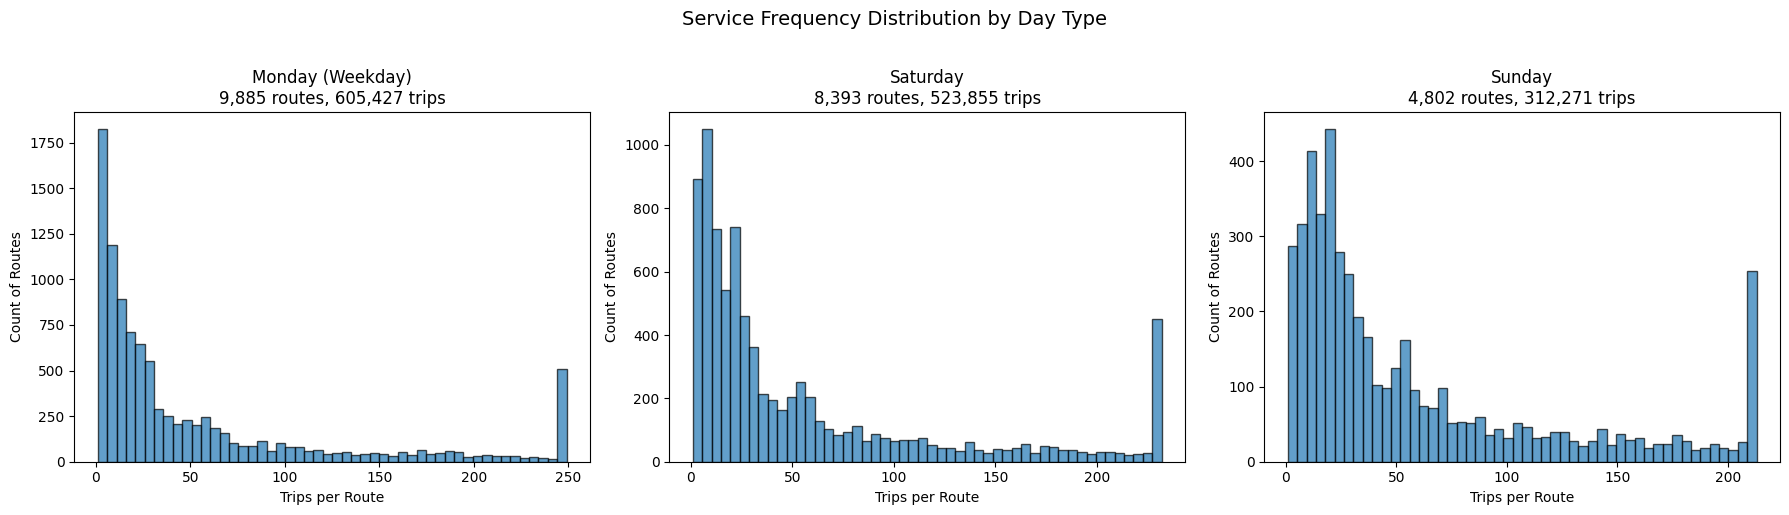


=== Weekend Service Coverage ===
  Routes with weekday service: 9,885
  Routes with Saturday service: 8,393 (84.9% of weekday)
  Routes with Sunday service: 4,802 (48.6% of weekday)
  Weekday-only routes: 1,713

  For routes running both weekday+Saturday (8,137):
    Sat/Weekday trip ratio: mean=1.10, median=0.96
    Routes with reduced Saturday service: 1,559
    Routes with similar Saturday service: 6,120


In [17]:
# Typical weekday vs weekend comparison
if all(d in route_day_trips for d in ['monday', 'saturday', 'sunday']):
    weekday = route_day_trips['monday']  # Monday as proxy for typical weekday
    saturday = route_day_trips['saturday']
    sunday = route_day_trips['sunday']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, data, title in zip(axes, [weekday, saturday, sunday], ['Monday (Weekday)', 'Saturday', 'Sunday']):
        ax.hist(data.clip(upper=data.quantile(0.95)), bins=50, edgecolor='black', alpha=0.7)
        ax.set_title(f'{title}\n{len(data):,} routes, {data.sum():,} trips')
        ax.set_xlabel('Trips per Route')
        ax.set_ylabel('Count of Routes')
    plt.suptitle('Service Frequency Distribution by Day Type', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Weekend service ratio
    all_routes = set(weekday.index) | set(saturday.index) | set(sunday.index)
    wk_routes = set(weekday.index)
    sat_routes = set(saturday.index)
    sun_routes = set(sunday.index)

    print(f"\n=== Weekend Service Coverage ===")
    print(f"  Routes with weekday service: {len(wk_routes):,}")
    print(f"  Routes with Saturday service: {len(sat_routes):,} ({100*len(sat_routes)/len(wk_routes):.1f}% of weekday)")
    print(f"  Routes with Sunday service: {len(sun_routes):,} ({100*len(sun_routes)/len(wk_routes):.1f}% of weekday)")
    print(f"  Weekday-only routes: {len(wk_routes - sat_routes - sun_routes):,}")

    # For routes running both weekday and weekend, compare frequencies
    shared = wk_routes & sat_routes
    if shared:
        wk_shared = weekday[weekday.index.isin(shared)]
        sat_shared = saturday[saturday.index.isin(shared)]
        ratio = sat_shared / wk_shared
        print(f"\n  For routes running both weekday+Saturday ({len(shared):,}):")
        print(f"    Sat/Weekday trip ratio: mean={ratio.mean():.2f}, median={ratio.median():.2f}")
        print(f"    Routes with reduced Saturday service: {(ratio < 0.8).sum():,}")
        print(f"    Routes with similar Saturday service: {((ratio >= 0.8) & (ratio <= 1.2)).sum():,}")

## 8. Operator × Route × Service Summary

Build a summary table: operator → route count → trip count → service days

In [18]:
# Build operator summary
route_trips = trips.groupby('route_id').size().reset_index(name='n_trips')
route_summary = routes.merge(route_trips, on='route_id', how='left')
route_summary = route_summary.merge(agency[['agency_id', 'agency_name']], on='agency_id', how='left')
route_summary['n_trips'] = route_summary['n_trips'].fillna(0).astype(int)

op_summary = route_summary.groupby('agency_name').agg(
    n_routes=('route_id', 'count'),
    total_trips=('n_trips', 'sum'),
    mean_trips_per_route=('n_trips', 'mean'),
    max_trips=('n_trips', 'max'),
).sort_values('n_routes', ascending=False)

print("=== Operator Summary (top 20) ===")
print(op_summary.head(20).to_string())

# Save for later use
op_summary.to_csv(Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit') / 'bods_operator_summary.csv')
print("\nSaved operator summary to data/audit/bods_operator_summary.csv")

=== Operator Summary (top 20) ===
                                            n_routes  total_trips  mean_trips_per_route  max_trips
agency_name                                                                                       
Bee Network                                      579        45797             79.096718       2145
Stagecoach East Scotland                         327        31379             95.960245       2156
Stagecoach East Midlands                         278        24757             89.053957       1359
Stagecoach West Scotland                         259        24532             94.718147        580
National Express                                 242         7163             29.599174        294
Stagecoach Midlands                              215        21551            100.237209       1214
Go North East                                    210        13801             65.719048        671
Stagecoach South East                            209        14614          

## 9. Feed Info — Data Provenance

What regions does each feed cover? When was data published?

In [19]:
print("=== Feed Information ===")
print(feed_info.to_string(index=False))

=== Feed Information ===
         feed_publisher_name               feed_publisher_url feed_lang  feed_start_date  feed_end_date    feed_version
Bus Open Data Service (BODS) https://www.bus-data.dft.gov.uk/        EN         20260311       21250928 20260311_034531


## 10. Key Findings & Implications for Pipeline

Summarize what we learned and what it means for the data pipeline.

In [20]:
print("=" * 80)
print("  BODS DEEP DIVE — KEY FINDINGS")
print("=" * 80)

print(f"""
1. SCALE
   - {len(routes):,} routes, {len(trips):,} trips, {total_rows:,} stop_times records
   - {len(stops):,} unique GTFS stops, {len(agency):,} operators

2. SERVICE FREQUENCY
   - Huge variation: some stops get thousands of visits, others <10
   - Underserved stops (≤10 visits total): {(stop_freq['total_visits'] <= 10).sum():,}
   - Clear AM/PM peak pattern in time-of-day distribution

3. WEEKEND COVERAGE
   - Significant reduction in weekend service vs weekday
   - Sunday is the weakest day for bus coverage
   - Some routes are weekday-only — no weekend alternative

4. MARKET CONCENTRATION
   - Top 5 operators control {top5_share:.0f}% of routes
   - HHI = {hhi:.0f} — {'highly concentrated' if hhi > 2500 else 'moderately concentrated' if hhi > 1500 else 'competitive'} market

5. PIPELINE IMPLICATIONS
   - Stop count alone is INSUFFICIENT — must include frequency metrics
   - Derive: trips_per_stop_weekday, trips_per_stop_saturday, trips_per_stop_sunday
   - Derive: first_service_time, last_service_time per stop
   - Derive: peak_vs_offpeak_ratio per stop
   - Route deduplication MUST happen before frequency counting
   - Need to join BODS stop_id → NaPTAN ATCOCode → LSOA for spatial analysis
""")

# Save stop frequency data for later notebooks
stop_freq.to_parquet(
    Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit') / 'bods_stop_frequency.parquet',
    index=False
)
print("Saved stop frequency data to data/audit/bods_stop_frequency.parquet")
print("\n02b — BODS Deep Dive: DONE")

  BODS DEEP DIVE — KEY FINDINGS

1. SCALE
   - 13,640 routes, 1,752,443 trips, 68,685,917 stop_times records
   - 310,598 unique GTFS stops, 651 operators

2. SERVICE FREQUENCY
   - Huge variation: some stops get thousands of visits, others <10
   - Underserved stops (≤10 visits total): 45,938
   - Clear AM/PM peak pattern in time-of-day distribution

3. WEEKEND COVERAGE
   - Significant reduction in weekend service vs weekday
   - Sunday is the weakest day for bus coverage
   - Some routes are weekday-only — no weekend alternative

4. MARKET CONCENTRATION
   - Top 5 operators control 12% of routes
   - HHI = 85 — competitive market

5. PIPELINE IMPLICATIONS
   - Stop count alone is INSUFFICIENT — must include frequency metrics
   - Derive: trips_per_stop_weekday, trips_per_stop_saturday, trips_per_stop_sunday
   - Derive: first_service_time, last_service_time per stop
   - Derive: peak_vs_offpeak_ratio per stop
   - Route deduplication MUST happen before frequency counting
   - Need t